# Birth-percentile regression from corrected biometry (from scratch)

**Data (no intermediate .npz — everything from source):**
- Corrected biometry (single eco scan, manually cleaned): `IMPACT_ecocardio_zscores_corrected.xlsx` — raw mm/g in `PA/PC/DBP/LF/EFW_ecoIMPACT`, GA in `EG_ecoIMPACT`, birth pct in `percentil_birth`.
- **IG-21 z-scores computed with the official INTERGROWTH-21st standard** (`fgm.centiles`, coefficients transcribed from the peer-reviewed `gigs` R package — Papageorghiou 2014 biometry, Stirnemann 2017 EFW-LMS). Verified to reproduce the stored `*_z_ig21` columns to ~1e-15.
- Appearance-lag per fetus from `_perimage_lag_citus.csv` (raw + GA-debiased).

**Pipeline:** official raw→z conversion → merge lag+birth → Ridge 5-fold GroupKFold, predictions clipped [0,100] → per-fetus incremental diagnostics.

*No masking. The corrected file already has impossible values hand-fixed. Two corrupt cells are MASKED (zeroed, fetus kept): fetus 94 HC (z −19.3, |z|>10) and fetus 1008 EFW (z +8.9 vs body z ≈ −5, inconsistent). Same rule the canonical pipeline uses.*

In [ ]:
import sys, numpy as np, pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

FGM  = "/Users/tiago/PythonProject/fetal_growth_mechanism"      # holds fgm.centiles (official IG-21)
IMG  = "/Users/tiago/PythonProject/fgr-geometry/results/img_align"
CORR = "/Users/tiago/Downloads/OneDrive_1_7-9-2026/IMPACT_ecocardio_zscores_corrected.xlsx"
sys.path.insert(0, FGM)
from fgm import centiles          # official INTERGROWTH-21st standard
centiles.validate()               # asserts mu(32wk) matches published centiles, median z=0

validate(): INTERGROWTH-21st mu(32wk) matches published centiles; median z=0. OK


## 1. Convert corrected raw biometry → IG-21 z (official standard)

In [ ]:
cf = pd.read_excel(CORR, sheet_name="ecocardio_corrected")
cf["Cod"] = pd.to_numeric(cf["Cod"], errors="coerce")
cf = cf.dropna(subset=["Cod"]).drop_duplicates("Cod").set_index("Cod")
ga = pd.to_numeric(cf["EG_ecoIMPACT"], errors="coerce").to_numpy(float)
# centiles.biometry_z expects MILLIMETRES; EFW in grams. Feature order ac,hc,bpd,fl,efw.
z = pd.DataFrame(index=cf.index)
z["ac"]  = centiles.biometry_z(pd.to_numeric(cf["PA_ecoIMPACT"], errors="coerce").to_numpy(float), ga, "ac")
z["hc"]  = centiles.biometry_z(pd.to_numeric(cf["PC_ecoIMPACT"], errors="coerce").to_numpy(float), ga, "hc")
z["bpd"] = centiles.biometry_z(pd.to_numeric(cf["DBP_ecoIMPACT"],errors="coerce").to_numpy(float), ga, "bpd")
z["fl"]  = centiles.biometry_z(pd.to_numeric(cf["LF_ecoIMPACT"], errors="coerce").to_numpy(float), ga, "fl")
z["efw"] = centiles.efw_z(       pd.to_numeric(cf["EFW_ecoIMPACT"],errors="coerce").to_numpy(float), ga)
z["ga"]   = ga
z["bpct"] = pd.to_numeric(cf["percentil_birth"], errors="coerce").to_numpy(float)
for m in ["ac","hc","bpd","fl","efw"]: print(f"  {m}: [{z[m].min():.1f},{z[m].max():.1f}]  mean {z[m].mean():.2f} sd {z[m].std():.2f}")

  ac: [-4.5,4.2]  mean 0.49 sd 1.08
  hc: [-19.3,4.3]  mean 0.10 sd 1.35
  bpd: [-6.3,3.3]  mean -0.88 sd 1.12
  fl: [-3.6,4.3]  mean 0.51 sd 1.12
  efw: [-2.8,8.9]  mean 0.49 sd 0.87


## 2. Merge appearance-lag; mask corrupt cells (z < −10 or EFW-inconsistent)

In [ ]:
pl = pd.read_csv(f"{IMG}/_perimage_lag_citus.csv")
pl["ga_bin"]  = pl["true_ga"].round().astype(int)
pl["lag_deb"] = pl["lag"] - pl.groupby("ga_bin")["lag"].transform("mean")
z = z.merge(pl.groupby("fid")["lag"].mean().rename("lag_raw"),     left_index=True, right_index=True, how="left")
z = z.merge(pl.groupby("fid")["lag_deb"].mean().rename("lag_deb"), left_index=True, right_index=True, how="left")

# MASKING criterion (keep the fetus, zero only the corrupt cell):
#   (1) magnitude:     z < -10  (agreed rule)            -> physiologically impossible sentinel
#   (2) inconsistency: |efw_z - median(body z)| > 6      -> EFW contradicts the 4 body measures
ZC = ["ac","hc","bpd","fl","efw"]; BODY = ["ac","hc","bpd","fl"]
masked = []
for m in ZC:
    bad = z[m] < -10
    for f in z.index[bad]: masked.append((int(f), m, round(z.loc[f,m],1)))
    z.loc[bad, m] = 0.0
inc = (z["efw"] - z[BODY].median(axis=1)).abs() > 6
for f in z.index[inc]: masked.append((int(f), "efw", round(z.loc[f,"efw"],1)))
z.loc[inc, "efw"] = 0.0
D = z.dropna(subset=ZC+["ga","bpct"])
print("masked cells:", masked, "| cohort kept, n:", len(D), "| with lag:", D["lag_raw"].notna().sum())

masked cells: [(94, 'hc', np.float64(-19.3)), (1008, 'efw', np.float64(8.9))] | cohort kept, n: 977 | with lag: 935


## 3. Ridge regression, 5-fold GroupKFold, predictions clipped [0,100]

In [ ]:
ZC=["ac","hc","bpd","fl","efw"]
sub=D[D["lag_raw"].notna()]; Y=sub["bpct"].values; GR=sub.index.values
B=sub[ZC].values; G=sub["ga"].values[:,None]; LR=sub["lag_raw"].values[:,None]; LD=sub["lag_deb"].values[:,None]
def oof(X):
    p=np.zeros(len(Y))
    for tr,te in GroupKFold(5).split(X,Y,GR): p[te]=Ridge(1.0).fit(X[tr],Y[tr]).predict(X[te])
    return np.clip(p,0,100)
S={"GA only":G,"lag only":LR,"biometry":B,"biometry+GA":np.column_stack([B,G]),
   "biometry+lag":np.column_stack([B,LR]),"biometry+GA+lag":np.column_stack([B,G,LR])}
P={k:oof(v) for k,v in S.items()}
for k in S: r=pearsonr(P[k],Y)[0]; print(f"  {k:16s} r={r:+.3f} R2={r**2:.3f}")
rng=np.random.RandomState(0); n=len(Y); idx=[rng.randint(0,n,n) for _ in range(2000)]
def boot(a,b): return np.array([pearsonr(P[a][ix],Y[ix])[0]-pearsonr(P[b][ix],Y[ix])[0] for ix in idx])
STATS={}
for name,full in [("biometry + lag","biometry+lag"),("biometry + GA","biometry+GA"),("biometry + GA + lag","biometry+GA+lag")]:
    d=boot(full,"biometry"); STATS[name]=(d.mean(),np.percentile(d,2.5),np.percentile(d,97.5),np.mean(d>0))
    print(f"  {name:22s} vs biometry  dr={d.mean():+.3f} CI[{np.percentile(d,2.5):+.3f},{np.percentile(d,97.5):+.3f}] P={np.mean(d>0):.2f}")

  GA only          r=-0.070 R2=0.005
  lag only         r=+0.182 R2=0.033
  biometry         r=+0.622 R2=0.386
  biometry+GA      r=+0.625 R2=0.390
  biometry+lag     r=+0.627 R2=0.393
  biometry+GA+lag  r=+0.635 R2=0.403
  biometry + lag         vs biometry  dr=+0.006 CI[-0.001,+0.013] P=0.96
  biometry + GA          vs biometry  dr=+0.003 CI[-0.004,+0.010] P=0.80
  biometry + GA + lag    vs biometry  dr=+0.013 CI[+0.001,+0.025] P=0.99


## 4. Per-fetus incremental diagnostics (the plot)

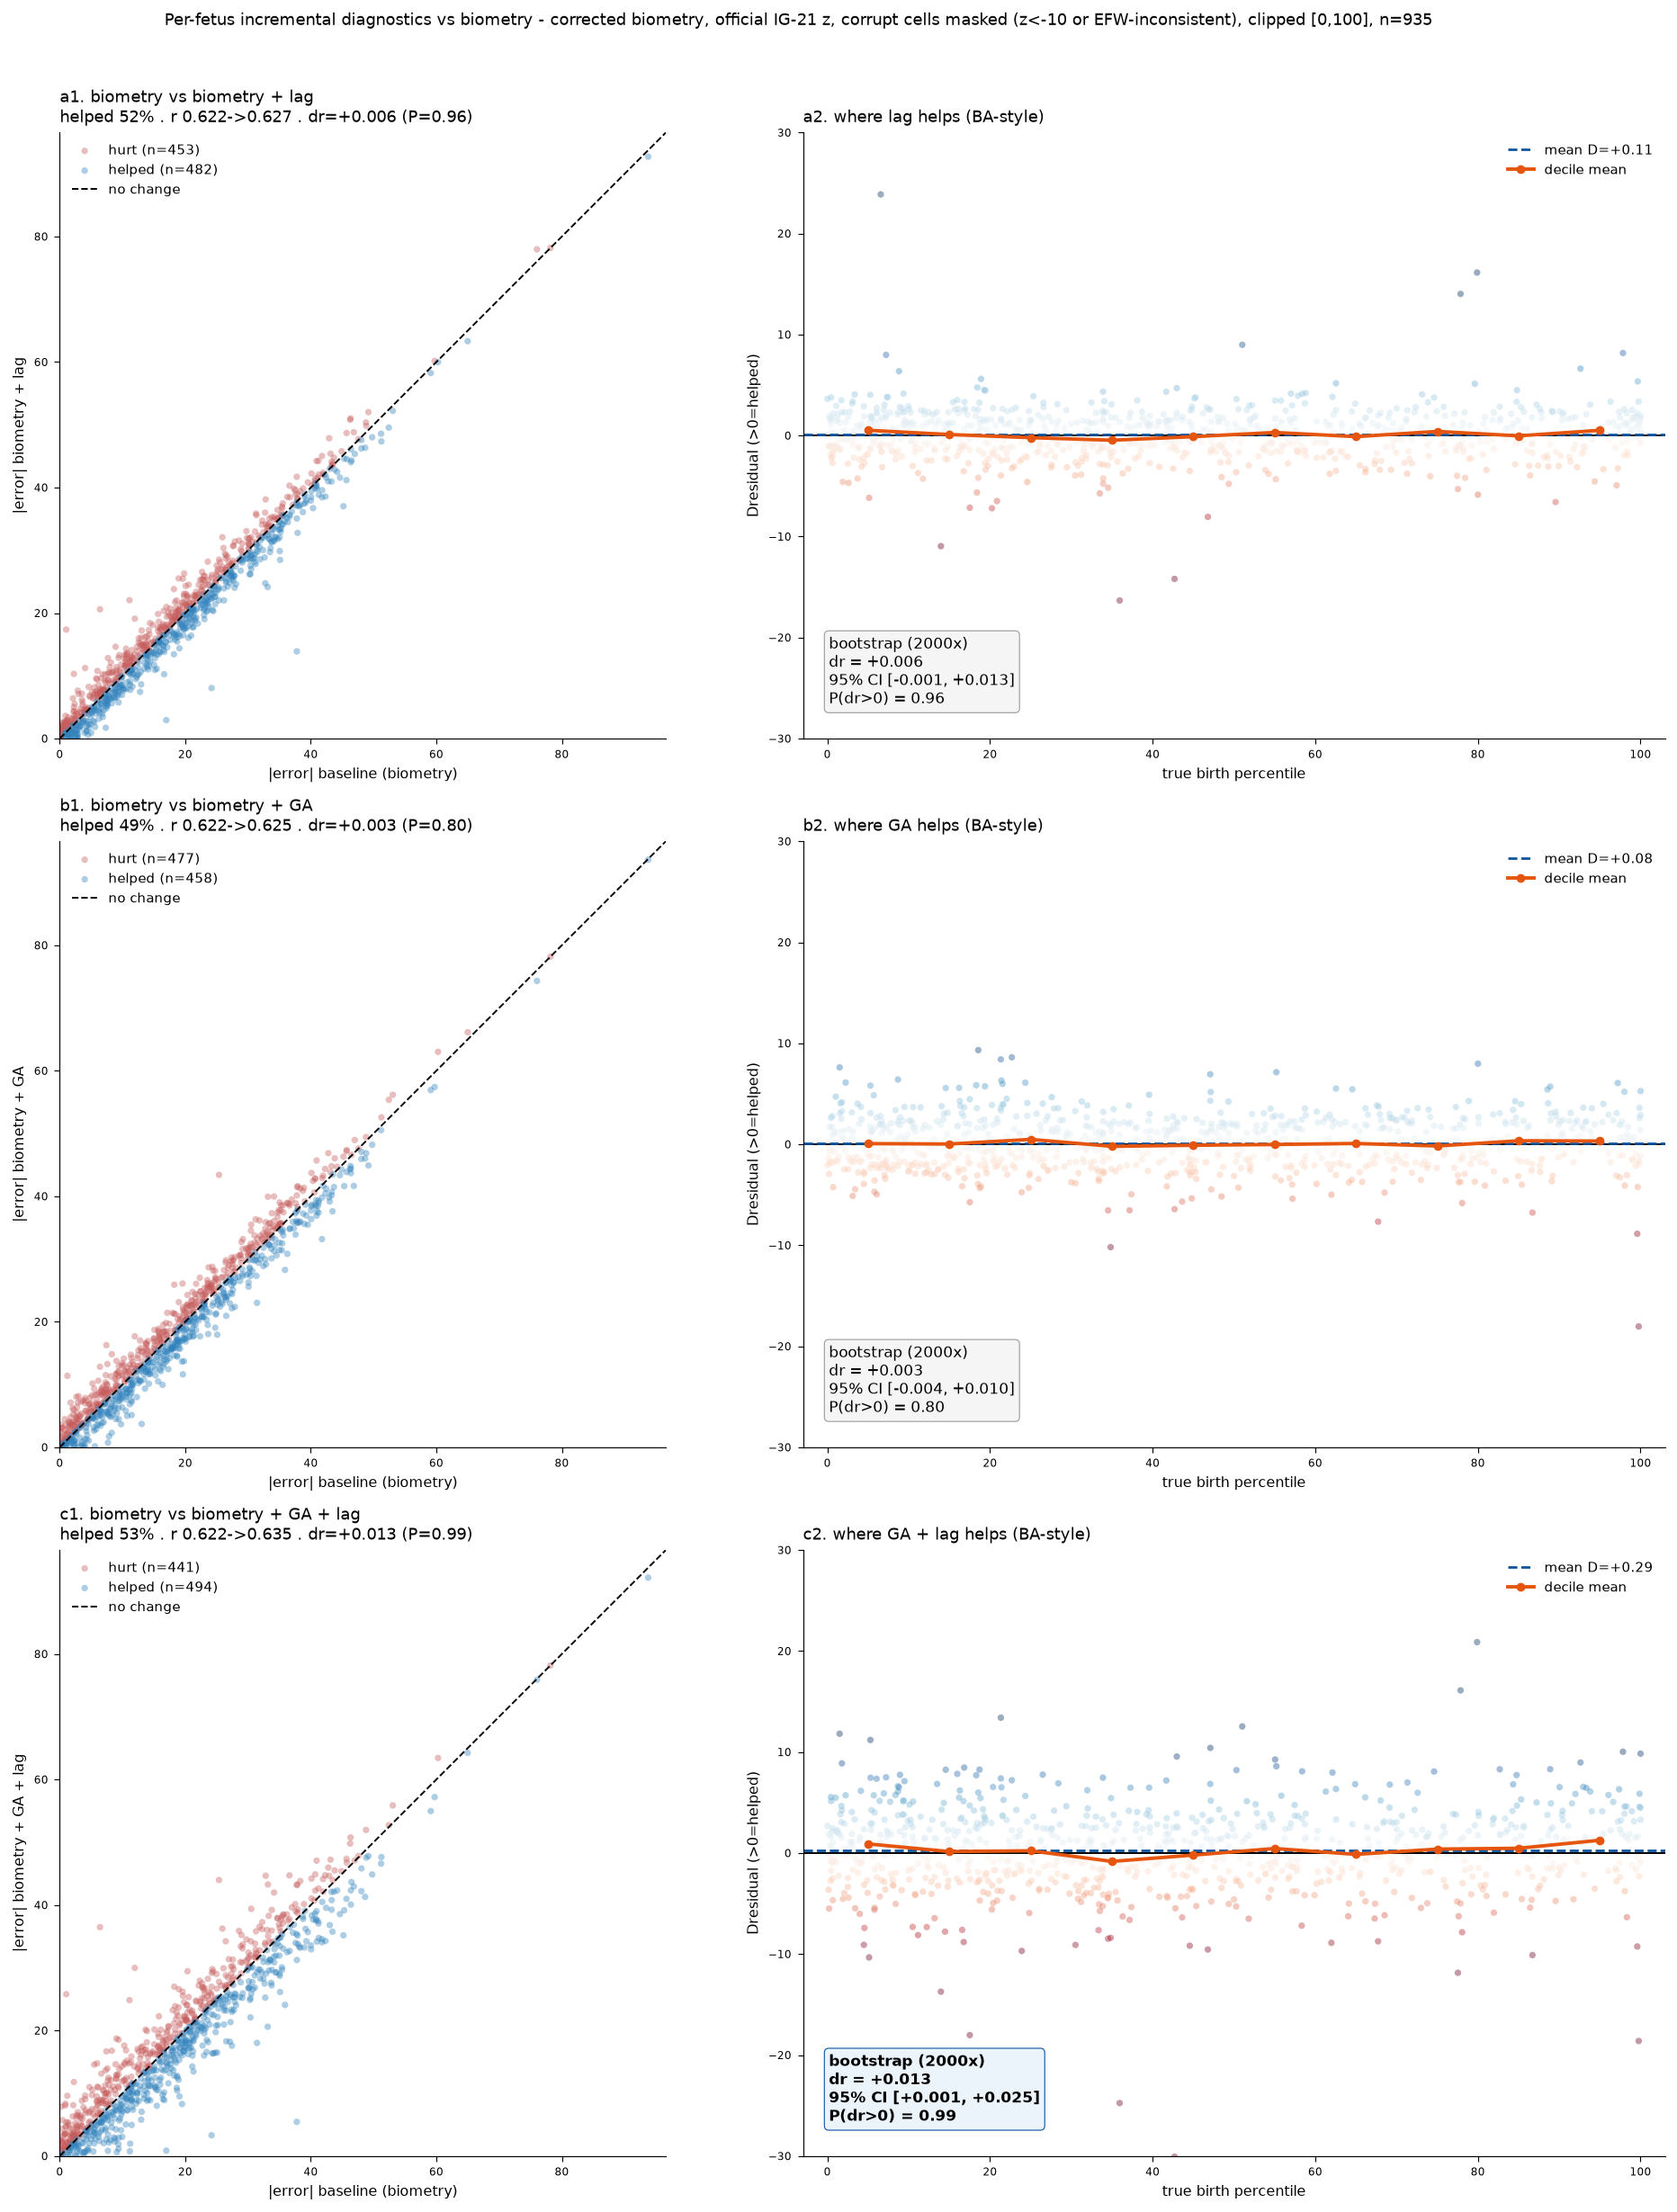

In [ ]:
base=P["biometry"]; eb=np.abs(Y-base)
comps=[("biometry + lag",P["biometry+lag"]),("biometry + GA",P["biometry+GA"]),("biometry + GA + lag",P["biometry+GA+lag"])]
fig,ax=plt.subplots(3,2,figsize=(14,17.5))
lim=[0,max(eb.max(),max(np.abs(Y-c[1]).max() for c in comps))*1.03]
bins=np.linspace(0,100,11); ctr=(bins[:-1]+bins[1:])/2
for k,(name,full) in enumerate(comps):
    ef=np.abs(Y-full); d=eb-ef; h=d>0; dr,lo,hi,pv=STATS[name]; strong=pv>=0.975
    a=ax[k,0]
    a.scatter(eb[~h],ef[~h],s=14,alpha=.4,color="#c65b5b",edgecolor="none",label=f"hurt (n={(~h).sum()})")
    a.scatter(eb[h],ef[h],s=14,alpha=.4,color="#3182bd",edgecolor="none",label=f"helped (n={h.sum()})")
    a.plot(lim,lim,"k--",lw=1,label="no change"); a.set_xlim(lim); a.set_ylim(lim); a.set_aspect("equal")
    a.set_xlabel("|error| baseline (biometry)"); a.set_ylabel(f"|error| {name}")
    a.set_title(f"{chr(97+k)}1. biometry vs {name}\nhelped {100*h.mean():.0f}% . r {pearsonr(base,Y)[0]:.3f}->{pearsonr(full,Y)[0]:.3f} . dr={dr:+.3f} (P={pv:.2f})",fontsize=9.5)
    a.legend(fontsize=7.5,loc="upper left",framealpha=.9)
    b=ax[k,1]
    b.scatter(Y,d,s=14,alpha=.4,c=d,cmap="RdBu",vmin=-10,vmax=10,edgecolor="none")
    b.axhline(0,color="k",lw=1); b.axhline(d.mean(),color="#08519c",ls="--",lw=1.4,label=f"mean D={d.mean():+.2f}")
    b.plot(ctr,[d[(Y>=bins[i])&(Y<bins[i+1])].mean() for i in range(10)],color="#e6550d",lw=2,marker="o",ms=4,label="decile mean")
    b.set_xlabel("true birth percentile"); b.set_ylabel("Dresidual (>0=helped)"); b.set_ylim(-30,30); b.set_xlim(-3,103)
    b.text(0.03,0.05,f"bootstrap (2000x)\ndr = {dr:+.3f}\n95% CI [{lo:+.3f}, {hi:+.3f}]\nP(dr>0) = {pv:.2f}",transform=b.transAxes,fontsize=8.5,va="bottom",ha="left",
           bbox=dict(boxstyle="round",fc="#eaf3fb" if strong else "#f5f5f5",ec="#08519c" if strong else "#999",alpha=.95),fontweight="bold" if strong else "normal")
    b.set_title(f"{chr(97+k)}2. where {name.split('+',1)[1].strip()} helps (BA-style)",fontsize=9.5); b.legend(fontsize=7.5,loc="upper right",framealpha=.9)
fig.suptitle(f"Per-fetus incremental diagnostics vs biometry - corrected biometry, official IG-21 z, corrupt cells masked (z<-10 or EFW-inconsistent), clipped [0,100], n={len(sub)}",fontsize=9.5,y=0.999)
fig.tight_layout(rect=[0,0,1,0.986]); plt.show()

## 5. Export per-fetus table (Excel)

In [ ]:
RAW={"ac":"PA_ecoIMPACT","hc":"PC_ecoIMPACT","bpd":"DBP_ecoIMPACT","fl":"LF_ecoIMPACT","efw":"EFW_ecoIMPACT"}
out=pd.DataFrame(index=D.index)
for m,col in RAW.items():
    out[f"{m}_raw"]=pd.to_numeric(cf[col],errors="coerce").reindex(out.index); out[f"{m}_z_ig21"]=D[m].round(3)
out["ga_weeks"]=D["ga"].round(2); out["lag_raw"]=D["lag_raw"].round(3)
out["lag_debiased"]=D["lag_deb"].round(3); out["birth_percentile"]=D["bpct"].round(1)
out.index.name="Cod"; out.reset_index().to_excel("lag_regression_data.xlsx",index=False,sheet_name="per_fetus")
print("wrote lag_regression_data.xlsx", out.shape)

wrote lag_regression_data.xlsx (977, 14)
